In [27]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from scipy.ndimage import gaussian_filter1d
from neo.io import BlackrockIO


### Objective
1. Load neur data, psychopy data, trigger data
2. Extract spikes and FRs for each trial, neuron, epoch
3. Visualize spikes and FRs for random neuron-trial pair and all pairs (heatmap)

In [28]:
patient = 21

### 1. df_neurs

In [29]:
# df_neurs = final_neur_df.copy()
df_neurs = pd.read_parquet(f'../../results/2025{patient}/records/processed_data/df_neurs.parquet')

eg_spikes = df_neurs['spikes'].iloc[0]
print("last 5 spikes (s):", eg_spikes[-5:])
print("last 5 spikes (min):", eg_spikes[-5:] / 60)

n_neurs = len(df_neurs)
df_neurs


last 5 spikes (s): [1737.31346667 1737.37963333 1738.62076667 1740.39936667 1740.55433333]
last 5 spikes (min): [28.95522444 28.95632722 28.97701278 29.00665611 29.00923889]


,patient,chanID,unitID,spikes,num_spikes,FR,region,x,y,z
0,21,219,1709,"[5.8342, 33.16630000000001, 34.1727, 34.288, 3...",2786,1.606023,mRAHIP8,21.000004,-1.29937,-15.600003
1,21,218,3888,"[0.3418666666666667, 0.6712, 1.758166666666666...",3976,2.241688,mRAHIP7,18.600004,-1.29937,-15.600003
2,21,218,3887,"[0.34526666666666667, 0.3496, 0.35416666666666...",15705,8.859160,mRAHIP7,18.600004,-1.29937,-15.600003
3,21,218,3845,"[186.2033, 189.2548666666667, 189.284366666666...",3452,2.174044,mRAHIP7,18.600004,-1.29937,-15.600003
4,21,220,2374,"[10.1639, 32.283433333333335, 35.6210666666666...",710,0.406395,220,NaN,NaN,NaN
5,21,220,2305,"[34.1908, 34.4417, 34.516533333333335, 34.5623...",13423,7.790637,220,NaN,NaN,NaN
6,21,222,878,"[0.05560000000000001, 0.7493333333333334, 0.82...",3460,1.949670,222,NaN,NaN,NaN
7,21,223,2489,"[0.047733333333333336, 0.1006, 0.1926, 0.2007,...",2159,1.216535,223,NaN,NaN,NaN
8,21,223,2492,"[2.8509333333333333, 3.1158333333333337, 3.505...",5723,3.261753,223,NaN,NaN,NaN
9,21,224,3097,"[5.0144, 5.237, 32.37466666666667, 34.28296666...",11870,6.796445,224,NaN,NaN,NaN


### 2. df_trigs
note to work with relative instead of absolute time

In [30]:
# load
nev_file = glob.glob(f'../../results/2025{patient}/raw/*.nev')[0]
io = BlackrockIO(nev_file)
seg = io.read_block(lazy=False).segments[0]
dig_ev = [ev for ev in seg.events if "digital" in ev.name.lower()][0]

# map codes to labels
code_map = {
    10: "block started",
    20: "baseline started",
    30: "stim started",
    40: "delay started",
    50: "task started",
    51: "marker moved",
    52: "left pressed",
    53: "left released",
    54: "right pressed",
    55: "right released",
    56: "response submitted",
    60: "anticipation started",
    70: "feedback started",
    80: "block ended",
}

# build df
df_trigs_raw = pd.DataFrame({
    "trigger_code": dig_ev.labels.astype(int),
    "time": dig_ev.times.magnitude
})
df_trigs_raw["event"] = df_trigs_raw["trigger_code"].map(code_map)


# find index of 1st '10' (block started)
block1_start_idx = df_trigs_raw.index[df_trigs_raw["trigger_code"] == 10][0]
# align times relative to block1 start
df_trigs_raw["rel_time"] = df_trigs_raw["time"] - df_trigs_raw.loc[block1_start_idx, "time"]
# drop triggers before block1 start
df_trigs = df_trigs_raw[block1_start_idx:]
# drop abs time
df_trigs = df_trigs.drop(columns=['time']).reset_index(drop=True)

print(df_trigs['event'].value_counts(), end='\n\n')
print('Last 10 times in mins: ' + str(df_trigs['rel_time'][-10:].values / 60), end='\n\n')
df_trigs

event
baseline started        240
stim started            240
delay started           240
task started            240
anticipation started    240
feedback started        240
marker moved            234
response submitted      228
left pressed            138
left released           135
right pressed           130
right released          130
block started             6
block ended               6
Name: count, dtype: int64

Last 10 times in mins: [27.91275727 27.92942838 27.94750339 27.96414617 27.98888339 28.03776007
 28.03776285 28.03888896 28.04303563 28.05980396]



,trigger_code,event,rel_time
0,10,block started,0.000000
1,20,baseline started,25.235138
2,30,stim started,26.319604
3,40,delay started,27.321305
4,50,task started,28.606505
...,...,...,...
2444,51,marker moved,1682.265604
2445,54,right pressed,1682.265771
2446,60,anticipation started,1682.333338
2447,70,feedback started,1682.582138


### 3. df_psychopy

In [31]:
df_psychopy_all = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
df_psychopy = df_psychopy_all.loc[df_psychopy_all['subj'] == patient].reset_index(drop=True)
df_psychopy

,dir_flip,sess_flip,chosen_pos_aligned,div_pos_aligned,stim_pos,true_class,pred_class,err_type,invalid,incomplete,...,frameRate,expStart,Unnamed: 119,chosen_pos,Unnamed: 112,stim_ranks,resp_ranks,stim_ranks_aligned,resp_ranks_aligned,block_name
0,0.0,NaN,0.256,0.2,-0.10,0,1,1,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,0.256,NaN,10.5,53.0,-28.75,13.75,flat_comp_1.0
1,1.0,NaN,0.044,0.2,-0.14,0,0,0,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,-0.044,NaN,6.5,9.0,-32.75,-30.25,flat_comp_1.0
2,1.0,NaN,0.112,0.2,0.10,0,0,0,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,-0.112,NaN,30.5,21.5,-8.75,-17.75,flat_comp_1.0
3,1.0,NaN,0.228,0.2,0.38,1,1,0,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,-0.228,NaN,76.5,31.5,37.25,-7.75,flat_comp_1.0
4,1.0,NaN,0.292,0.2,0.14,0,1,1,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,-0.292,NaN,34.5,76.0,-4.75,36.75,flat_comp_1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,1.0,NaN,-0.140,-0.0,-0.38,0,0,0,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,0.140,NaN,2.5,11.0,-36.75,-28.25,baseline_1.0
236,0.0,NaN,-0.152,0.0,-0.14,0,0,0,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,-0.152,NaN,26.5,10.0,-12.75,-29.25,baseline_1.0
237,0.0,NaN,-0.136,0.0,-0.38,0,0,0,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,-0.136,NaN,2.5,12.0,-36.75,-27.25,baseline_1.0
238,1.0,NaN,0.152,-0.0,0.26,1,1,0,False,False,...,60.0,2025-12-12 15h14.59.626305 -0700,NaN,-0.152,NaN,66.5,73.0,27.25,33.75,baseline_1.0


### variables

In [32]:
# smoothing params
size, dt = .02, .01

# set epoch prestarts and durations (xlims)
epochs = ['baseline', 'stim', 'delay', 'response', 'feedback']
epoch_prestarts, epoch_durs = {}, {}

for epoch in epochs:

    # where to start x-axis
    if epoch == 'baseline': epoch_prestarts[epoch] = -0
    elif epoch == 'response': epoch_prestarts[epoch] = -1 # 1s before response submitted
    else: epoch_prestarts[epoch] = -.25

    # plot duration
    if epoch == 'delay': epoch_durs[epoch] = 1.5
    elif epoch == 'response': epoch_durs[epoch] = 0 # 0s after response submitted
    else: epoch_durs[epoch] = 1

print(f'prestarts (xlim start): {epoch_prestarts}')
print(f'durations: (xlim end): {epoch_durs}')
print()

# trial half prestarts and durations
trial_halves = ['trial pre-choice', 'trial post-choice']
trial_half_prestarts = {'trial pre-choice': -.25, 'trial post-choice': -1.25}
trial_half_durs      = {'trial pre-choice': 3.5,  'trial post-choice': 1.0}

print(f'trial half prestarts: {trial_half_prestarts}')
print(f'trial half durations: {trial_half_durs}')


prestarts (xlim start): {'baseline': 0, 'stim': -0.25, 'delay': -0.25, 'response': -1, 'feedback': -0.25}
durations: (xlim end): {'baseline': 1, 'stim': 1, 'delay': 1.5, 'response': 0, 'feedback': 1}

trial half prestarts: {'trial pre-choice': -0.25, 'trial post-choice': -1.25}
trial half durations: {'trial pre-choice': 3.5, 'trial post-choice': 1.0}


### helpers

In [33]:
def get_normed_FRs(FRs, base_FRs):
    # 1. trial-avged baseline, (neurons, 1)
    return FRs - base_FRs.mean(axis=(0, 2), keepdims=True)
    # 2. baseline FR per trial, (trials, neurons, 1), i.e.,avg across only timebins (axis=2)
    # return FRs - base_FRs.mean(axis=2, keepdims=True)
    # 3. no norming
    # return FRs


def get_epoch_spikes_and_FRs(df_trigs, df_neurs, epoch, size=size, dt=dt):
    ''' for each trial and neuron, get spike times and smoothed FRs (Hz) in epoch window
        df_trigs: trig times 
        df_neurs: spike times per neur '''

    epoch_prestart = epoch_prestarts[epoch]
    epoch_dur = epoch_durs[epoch]

    # bin edges & centers for hists & plots
    bin_edges = np.arange(epoch_prestart, epoch_dur + dt, dt)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    n_bins = len(bin_edges) - 1

    # get epoch start indices & times
    if epoch != 'response': epoch_start_rows = df_trigs[df_trigs['event'] == f'{epoch} started'].index
    # using anticipation started instead of response submitted bc sometimes they dont respond
    else: epoch_start_rows = df_trigs[df_trigs['event'] == 'anticipation started'].index
    epoch_starts = df_trigs.loc[epoch_start_rows, 'rel_time'].values

    # initialize 3d spike and 2d FR arrays
    n_trials = len(epoch_starts)
    trial_neur_spikes = np.empty((n_trials, len(df_neurs)), dtype=object)
    trial_neur_FRs = np.zeros((n_trials, len(df_neurs), n_bins))

    # per trial and neuron for current epoch
    for trial_idx in range(n_trials):
        for neur_idx, (_, neur_row) in enumerate(df_neurs.iterrows()):

            # obtain spike times and align
            trial_epoch_spikes = neur_row['spikes'][
                (neur_row['spikes'] >= epoch_starts[trial_idx] + epoch_prestart) &
                (neur_row['spikes'] <= epoch_starts[trial_idx] + epoch_dur)]
            trial_epoch_spikes = trial_epoch_spikes - epoch_starts[trial_idx]

            # bin and smooth
            counts, _ = np.histogram(trial_epoch_spikes, bins=bin_edges)
            smooth_spike_train = gaussian_filter1d(counts.astype(float), sigma=size/dt, mode='reflect', truncate=3.0)
            smooth_spike_train = smooth_spike_train / dt  # instantaneous FR (Hz): spikes/bin ÷ s/bin

            # store
            trial_neur_spikes[trial_idx, neur_idx] = trial_epoch_spikes
            trial_neur_FRs[trial_idx, neur_idx, :] = smooth_spike_train

    return trial_neur_spikes, trial_neur_FRs, bin_centers

### visualization 1

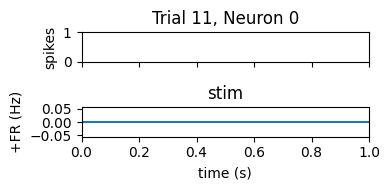

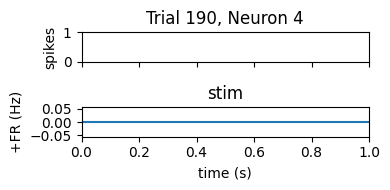

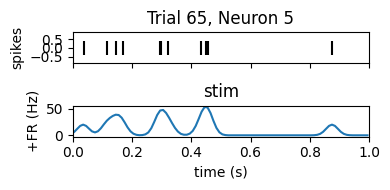

In [34]:
epoch = 'stim'
base_spikes, base_FRs, bin_centers = get_epoch_spikes_and_FRs(df_trigs, df_neurs, epoch)
n_trials, n_neurs = base_spikes.shape[:2]

for _ in range(3):

    rand_trial_idx, rand_neur_idx = np.random.randint(0, n_trials), np.random.randint(0, n_neurs)

    fig, ax = plt.subplots(2, 1, figsize=(4,2), sharex=True)

    spikes = base_spikes[rand_trial_idx, rand_neur_idx]
    ax[0].eventplot(spikes, colors='black', lineoffsets=0, linelengths=0.8)
    ax[0].set(title = f"Trial {rand_trial_idx}, Neuron {rand_neur_idx}", ylabel="spikes")

    fr = base_FRs[rand_trial_idx, rand_neur_idx]
    ax[1].plot(bin_centers, fr)
    ax[1].set(title = epoch, xlabel="time (s)", xlim=(0, 1), ylabel="+FR (Hz)")

    plt.tight_layout()
    plt.show()


### visualization 2

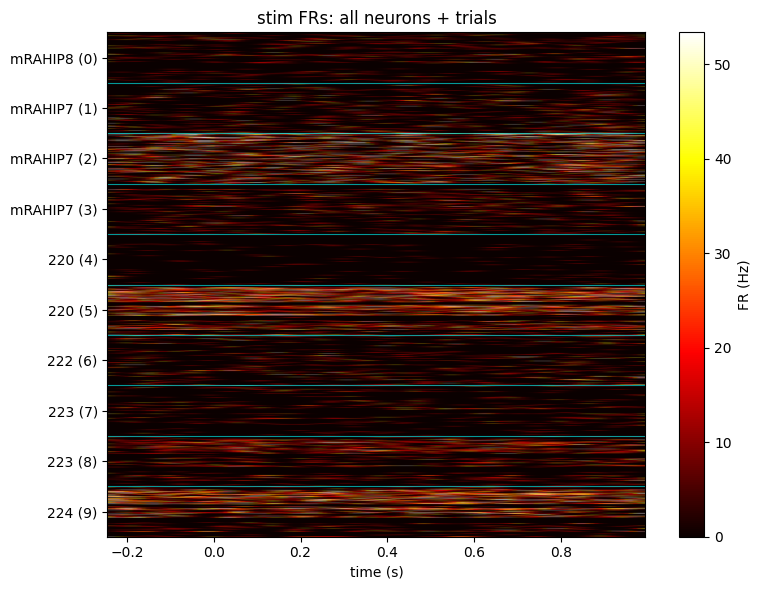

In [35]:
epoch = 'stim'
spikes, FRs, bin_centers = get_epoch_spikes_and_FRs(df_trigs, df_neurs, epoch, size, dt)

# heatmap of FRs: rows = neurons (grouped), columns = time bins
# within each neuron, stack all 240 trial rows → shape (n_neurs * n_trials, n_bins)
fr_stack = np.vstack([FRs[:, neur_id, :] for neur_id in range(n_neurs)])  # (n_neurs*n_trials, n_bins)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(fr_stack, aspect='auto', origin='upper',
                extent=[bin_centers[0], bin_centers[-1], fr_stack.shape[0], 0],
                cmap='hot',
                vmin=np.percentile(fr_stack, 1),
                vmax=np.percentile(fr_stack, 99))
plt.colorbar(im, ax=ax, label='FR (Hz)')

# draw horizontal lines between neurons
for neur_id in range(1, n_neurs):
    ax.axhline(neur_id * n_trials, color='cyan', linewidth=0.8, alpha=0.6)

# label each neuron band on y-axis
ax.set(title=f'{epoch} FRs: all neurons + trials',
       yticks=[neur_id * n_trials + n_trials / 2 for neur_id in range(n_neurs)],
       yticklabels=[f"{df_neurs['region'].iloc[i]} ({i})" for i in range(n_neurs)],
       xlabel='time (s)', )
plt.tight_layout()
plt.show()


### visualization 3

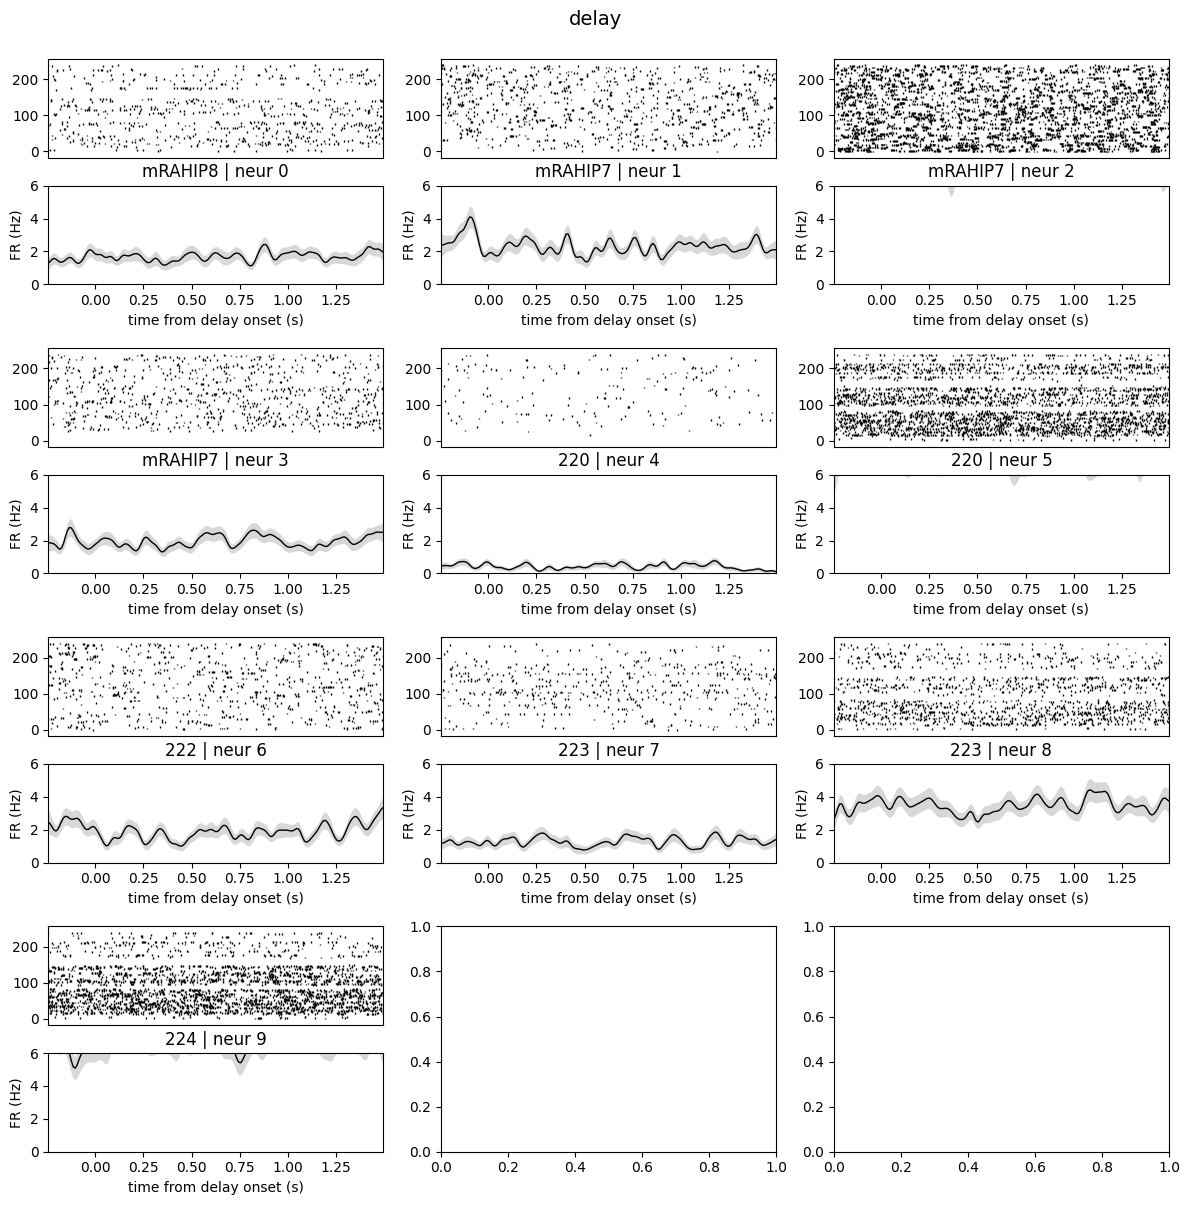

In [36]:
epoch = 'delay'
ymin, ymax = 0, 6 # optional

# get spikes & FRs
spikes, FRs, bin_centers = get_epoch_spikes_and_FRs(df_trigs, df_neurs, epoch, size, dt)
# choose whether norming or not
# if epoch!='baseline': FRs, yaxis_lab = get_normed_FRs(FRs, base_FRs), 'norm. '
# else: FRs, yaxis_lab = FRs.copy(), ''
FRs, yaxis_lab = FRs.copy(), ''

n_trials, n_neurs = FRs.shape[0], FRs.shape[1]

# ----- grid of neurons -----
n_cols = 3
n_rows = int(np.ceil(n_neurs / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axs, ax = axs.flatten(), 0

for neur_id in range(n_neurs):
    
    if ax >= len(axs): break

    # placeholder axes -> we’ll replace with 2 stacked axes
    ax_main = axs[ax]
    ss = ax_main.get_subplotspec()
    ax_main.remove()

    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # --------- RASTER ---------
    region = df_neurs["region"].iloc[neur_id]
    ax_raster.eventplot(spikes[:, neur_id], colors='k', lineoffsets=np.arange(n_trials), linelengths=5.0, linewidths=1.0)
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # --------- PSTH ---------
    data = FRs[:, neur_id, :] if epoch != 'baseline' else FRs[:, neur_id, :]
    mu = data.mean(axis=0)
    sderr = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])

    ax_psth.plot(bin_centers, mu, color='k', linewidth=1)
    ax_psth.fill_between(bin_centers, mu - sderr, mu + sderr,
                         color='0.7', alpha=0.5, linewidth=0)
    ax_psth.set(title=f"{region} | neur {neur_id}", xlim=(bin_centers[0], bin_centers[-1]),
                ylabel=f"{yaxis_lab}FR (Hz)", xlabel=f"time from {epoch} onset (s)",
                ylim=(ymin, ymax))

    ax += 1

plt.suptitle(epoch, y=1.0, fontsize=14)
plt.tight_layout()
plt.show()


### save patient df_trigs and epoch data (neur_df already saved in previous notebook)

In [37]:
processed_data_dir = f'../../results/2025{patient}/records/processed_data'
os.makedirs(processed_data_dir, exist_ok=True)
print(f'\nsaving to {processed_data_dir}')

# df_trigs: saves re-reading the raw .nev file
df_trigs.to_parquet(f'{processed_data_dir}/df_trigs.parquet')
print(f'df_trigs: ({len(df_trigs)} rows)')

# spikes/FRs for every epoch — the slow part neur4 should never redo
for epoch in epochs:
    print(f'\n{epoch}')
    ep_spikes, ep_FRs, ep_bc = get_epoch_spikes_and_FRs(df_trigs, df_neurs, epoch)
    np.save(f'{processed_data_dir}/{epoch}_spikes.npy', ep_spikes, allow_pickle=True)
    np.save(f'{processed_data_dir}/{epoch}_FRs.npy', ep_FRs)
    np.save(f'{processed_data_dir}/{epoch}_bin_centers.npy', ep_bc)
    print(f'spikes {ep_spikes.shape}, FRs {ep_FRs.shape}, bins {ep_bc.shape}')


saving to ../../results/202521/records/processed_data
df_trigs: (2449 rows)

baseline
spikes (240, 10), FRs (240, 10, 100), bins (100,)

stim
spikes (240, 10), FRs (240, 10, 125), bins (125,)

delay
spikes (240, 10), FRs (240, 10, 175), bins (175,)

response
spikes (240, 10), FRs (240, 10, 100), bins (100,)

feedback
spikes (240, 10), FRs (240, 10, 125), bins (125,)


plot electrode location

In [38]:
# template = datasets.load_mni152_template()

# # grab most distal channels for each electrode
# # IDs were different for older recording system (pt12)
# if patient == 12: plot_chanIDs = [97, 105, 113]
# else: plot_chanIDs = [193, 202, 210]

# coords_list = []
# for ch in plot_chanIDs:
#     row = df_neurs[df_neurs['chanID'] == ch].iloc[0]   # first match
#     coords_list.append([row.x, row.y, row.z])

# coords = np.array(coords_list)

# coord_regions  = ['OFC', 'ACC', 'HIP']
# colors = {'OFC':'red', 'ACC':'cyan', 'HIP':'orange'}
# marker_size = 20
# # x = sagittal, y = coronal, z = axial

# # 1. axial
# # fix z (axial)
# axial_cut = 0
# coords_ax = coords.copy()
# coords_ax[:,2] = axial_cut
# disp1 = plotting.plot_anat(template, display_mode='z', cut_coords=[axial_cut],
#                            cmap='gray', black_bg=True, draw_cross=False, colorbar=False)
# for (x,y,z), name in zip(coords_ax, coord_regions):
#     disp1.add_markers([(x,y,z)], marker_size=marker_size, marker_color=colors[name])
    
# # 2. sagittal (x=0)
# sag1_cut = 0
# coords_sag1 = coords.copy()
# coords_sag1[:,0] = sag1_cut
# disp2 = plotting.plot_anat(template, display_mode='x', cut_coords=[sag1_cut],
#                            cmap='gray', black_bg=True, draw_cross=False, colorbar=False)
# for (x,y,z), name in zip(coords_sag1, coord_regions):
#     disp2.add_markers([(x,y,z)], marker_size=marker_size, marker_color=colors[name])

# # 3. coronal (y=30)
# cor_cut = 0
# coords_cor = coords.copy()
# coords_cor[:,1] = cor_cut
# disp4 = plotting.plot_anat(template, display_mode='y', cut_coords=[cor_cut],
#                            cmap='gray', black_bg=True, draw_cross=False, colorbar=False)
# for (x,y,z), name in zip(coords_cor, coord_regions):
#     disp4.add_markers([(x,y,z)], marker_size=marker_size, marker_color=colors[name])

# plotting.show()

# print(colors)